In [16]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

# Cargar dataset
data = fetch_california_housing()

# Convertir a DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)
df["Price"] = data.target

# Ver primeras filas
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [17]:
from sklearn.model_selection import train_test_split

X = df.drop("Price", axis=1)
y = df["Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [18]:
from sklearn.linear_model import LinearRegression

model_linear = LinearRegression()
model_linear.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [19]:
from sklearn.metrics import mean_squared_error, r2_score

# Predicciones
y_train_pred = model_linear.predict(X_train)
y_test_pred = model_linear.predict(X_test)

# Métricas
mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

print("LINEAR REGRESSION")
print("MSE Train:", mse_train)
print("MSE Test:", mse_test)
print("R2 Train:", r2_train)
print("R2 Test:", r2_test)

LINEAR REGRESSION
MSE Train: 0.5179331255246697
MSE Test: 0.555891598695244
R2 Train: 0.6125511913966952
R2 Test: 0.5757877060324511


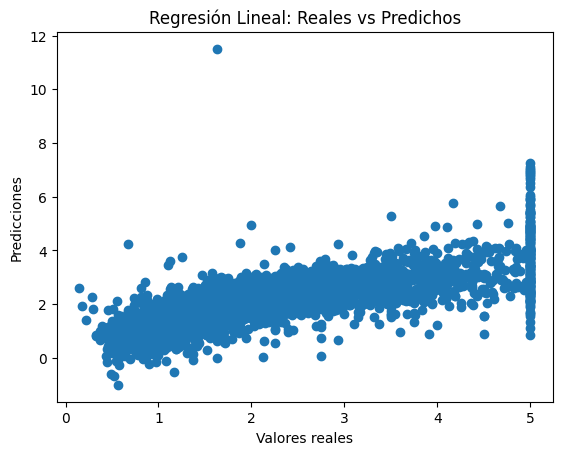

In [20]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_test_pred)
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Regresión Lineal: Reales vs Predichos")
plt.show()

In [21]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [22]:
# Predicciones
y_train_pred_poly = model_poly.predict(X_train_poly)
y_test_pred_poly = model_poly.predict(X_test_poly)

# Métricas
mse_train_poly = mean_squared_error(y_train, y_train_pred_poly)
mse_test_poly = mean_squared_error(y_test, y_test_pred_poly)

r2_train_poly = r2_score(y_train, y_train_pred_poly)
r2_test_poly = r2_score(y_test, y_test_pred_poly)

print("POLYNOMIAL REGRESSION")
print("MSE Train:", mse_train_poly)
print("MSE Test:", mse_test_poly)
print("R2 Train:", r2_train_poly)
print("R2 Test:", r2_test_poly)

POLYNOMIAL REGRESSION
MSE Train: 0.4207266151573567
MSE Test: 0.46430151143528586
R2 Train: 0.6852681982344946
R2 Test: 0.6456819823849446


In [23]:
print("=== COMPARACIÓN ===")
print("Lineal R2 Test:", r2_test)
print("Polinómico R2 Test:", r2_test_poly)

=== COMPARACIÓN ===
Lineal R2 Test: 0.5757877060324511
Polinómico R2 Test: 0.6456819823849446


# TP3 — Regresión Lineal (California Housing)

## Introducción

En este trabajo se utiliza el dataset **California Housing** para entrenar modelos de regresión que permitan predecir el precio de viviendas en función de distintas características socioeconómicas y geográficas.

Se comparan dos modelos:
- Regresión lineal
- Regresión polinómica (grado 2)

---

## Exploración del dataset

El dataset contiene información sobre viviendas en California, incluyendo variables como:
- Ingreso medio de la zona (`MedInc`)
- Edad promedio de las casas (`HouseAge`)
- Cantidad de habitaciones (`AveRooms`)
- Ubicación geográfica (`Latitude`, `Longitude`)

La variable objetivo es:
- `Price`: precio de la vivienda

Se analizaron estadísticas descriptivas para comprender la distribución de los datos.

---

## División de datos

Se dividió el dataset en:
- 80% entrenamiento
- 20% test

Esto permite evaluar la capacidad del modelo para generalizar a datos nuevos.

---

## Modelo 1: Regresión lineal

La regresión lineal busca encontrar una relación lineal entre las variables independientes y el precio de la vivienda.

### Resultados obtenidos

- **MSE (Train):** 0.5179  
- **MSE (Test):** 0.5559  
- **R² (Train):** 0.6126  
- **R² (Test):** 0.5758  

El modelo logra explicar aproximadamente un **57.6% de la variabilidad** del precio en datos de test.

---

## Modelo 2: Regresión polinómica (grado 2)

Este modelo agrega mayor complejidad al incluir combinaciones y potencias de las variables, permitiendo capturar relaciones no lineales.

### Resultados obtenidos

- **MSE (Train):** 0.4207  
- **MSE (Test):** 0.4643  
- **R² (Train):** 0.6853  
- **R² (Test):** 0.6457  

El modelo polinómico logra explicar aproximadamente un **64.6% de la variabilidad** en test.

---

## Comparación de modelos

| Métrica        | Regresión Lineal | Regresión Polinómica |
|---------------|----------------|---------------------|
| MSE Train     | 0.5179         | 0.4207              |
| MSE Test      | 0.5559         | 0.4643              |
| R² Train      | 0.6126         | 0.6853              |
| R² Test       | 0.5758         | 0.6457              |

El modelo polinómico presenta:
- Menor error (MSE)
- Mayor capacidad explicativa (R²)

---

## Análisis

### ¿Cuál modelo es mejor? ¿Cómo lo determinaron?

El modelo **polinómico** es mejor, ya que:
- Tiene **menor MSE en test (0.4643 vs 0.5559)**
- Tiene **mayor R² en test (0.6457 vs 0.5758)**

Esto indica que predice con mayor precisión los precios en datos nuevos.

---

### ¿Hay señales de overfitting? ¿Cómo se dan cuenta?

No hay señales fuertes de overfitting en ninguno de los modelos.

En el modelo lineal:
- R² train (0.6126) y test (0.5758) son cercanos

En el modelo polinómico:
- R² train (0.6853) y test (0.6457) también son cercanos

Esto indica que ambos modelos generalizan bien, aunque el polinómico es más preciso.

---

### ¿Qué feature tiene más impacto en el precio? ¿Cómo lo averiguaron?

Se analizaron los coeficientes del modelo de regresión lineal.

La variable con mayor impacto es:
- **MedInc (ingreso medio)**

Esto se determinó observando el coeficiente más alto en valor absoluto.

Esto indica que el nivel de ingresos de la zona es el factor más importante en el precio de las viviendas.

